### analyze_qpu_data — Fig. 10 hardware validation (FakeNighthawk, HVA ansatz)
###
### Cells:
###   0  — Imports & config
###   1  — Load data & labels
###   2  — Derived quantities (trajectories, E_∞, μ fits)
###   3  — (a)/(b) Convergence trajectories
###   4  — (c) E_∞ vs N_g
###   5  — (d) E_∞ - E_gs exponential fit (linear scale)
###  6  — (d') E_∞ - E_gs exponential fit (log-linear)
###   7  — (e) μ vs N_g power-law
###  8  — (f) Depolarising residual — signed
###   9  — (f') Depolarising residual — |residual| log scale
###   10 — Fit parameter table (LaTeX + matplotlib)

In [1]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import FuncFormatter
from scipy.optimize import curve_fit

os.makedirs("../../figures", exist_ok=True)
plt.rcParams.update({"font.size": 18})
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["text.usetex"] = False

_mfmt = FuncFormatter(lambda x, _: f"${x:g}$")

In [2]:
with open("../../results/hardware/ibm_nighthawk_zne_raw.pkl", "rb") as f:
    data = pickle.load(f)

with open("../../results/hardware/ibm_nighthawk_baseline_raw.pkl", "rb") as f:
    _baseline = pickle.load(f)

noiseless_results = data["noiseless_results"]
mitigated_results = data["mitigated_results"]
exact_energy      = data["exact_energy"]
beta_fit          = data["beta_fit"]   # noiseless β saved by simulation script
kappa_fit         = data["kappa_fit"]  # noiseless κ saved by simulation script
eps_eff           = data.get("eps_eff")
config            = data["config"]

MITIGATION_LABEL = (
    f"ZNE/{config['zne_factory_type']}/{config['zne_folding_method']}-fold"
    if config.get("use_zne", False) else
    "Twirl" if config.get("use_pauli_twirling", False) else
    "noisy"
)

layer_list = sorted(noiseless_results.keys())
Ng_arr     = np.array([noiseless_results[ld]["Ng"] for ld in layer_list], dtype=float)
gate_ctt   = Ng_arr.astype(int)
n_lay      = len(layer_list)
colors     = plt.cm.tab10(np.linspace(0, 0.9, n_lay))

print(f"Layers      : {layer_list}")
print(f"Ng values   : {gate_ctt}")
print(f"Exact energy: {exact_energy:.6f}")
print(f"Mitigation  : {MITIGATION_LABEL}")
print(f"eps_eff     : {eps_eff}")

Layers      : [1, 2, 3, 4, 5, 6]
Ng values   : [145 265 385 505 625 745]
Exact energy: -7.711545
Mitigation  : ZNE/linear/gate-fold
eps_eff     : 0.00030007850908220224


In [3]:
config

{'ansatz': 'hva',
 'hamiltonian': 'heisenberg',
 'use_zne': True,
 'use_pauli_twirling': True,
 'zne_scale_factors': [1, 3],
 'zne_factory_type': 'linear',
 'zne_folding_method': 'gate',
 'layer_depths': [1, 2, 3, 4, 5, 6],
 'num_seeds': 20,
 'optimizer': 'cobyla'}

## Cell 2 — Derived quantities
### Convergence trajectories, E_∞, μ fits, power-law fit for μ

In [4]:
def _padded_mean_std(histories):
    max_l  = max(len(h) for h in histories)
    padded = np.array([list(h) + [h[-1]] * (max_l - len(h)) for h in histories])
    return np.mean(padded, axis=0), np.std(padded, axis=0)

def exp_model(t, a, b):
    return a * np.exp(-b * t)

def noiseless_power_model(Ng, a, b):
    return a * (Ng ** -b)

def lin_model(x, a, b):
    return a * x + b

# ── Trajectories and E_∞ ──────────────────────────────────────────────────────
nl_mean_traj, nl_std_traj   = {}, {}
mit_mean_traj, mit_std_traj = {}, {}
val_list_idm, val_list_ids  = [], []
mit_val_m,    mit_val_s     = [], []

for ld in layer_list:
    m, s = _padded_mean_std(noiseless_results[ld]["cost_histories"])
    nl_mean_traj[ld], nl_std_traj[ld] = m, s
    val_list_idm.append(np.mean(noiseless_results[ld]["final_energies"]))
    val_list_ids.append(np.std(noiseless_results[ld]["final_energies"]))

    m, s = _padded_mean_std(mitigated_results[ld]["cost_histories"])
    mit_mean_traj[ld], mit_std_traj[ld] = m, s
    mit_val_m.append(np.mean(mitigated_results[ld]["final_energies"]))
    mit_val_s.append(np.std(mitigated_results[ld]["final_energies"]))

val_list_idm = np.array(val_list_idm)
val_list_ids = np.array(val_list_ids)
mit_val_m    = np.array(mit_val_m)
mit_val_s    = np.array(mit_val_s)

# ── Noisy baseline (no mitigation) ───────────────────────────────────────────
# _baseline config has use_zne=False, use_pauli_twirling=False;
# the noisy unmitigated runs are stored under "mitigated_results" in that file.
_bl_noisy  = _baseline["mitigated_results"]
_bl_layers = sorted(_bl_noisy.keys())
val_ny_m   = np.array([np.mean(_bl_noisy[ld]["final_energies"]) for ld in _bl_layers])
val_ny_s   = np.array([np.std(_bl_noisy[ld]["final_energies"])  for ld in _bl_layers])
_bl_Ng     = np.array([_bl_noisy[ld]["Ng"] for ld in _bl_layers], dtype=int)

# ── μ per seed ────────────────────────────────────────────────────────────────
def fit_mu(history, E_inf, max_iters=None):
    t  = np.arange(len(history), dtype=float)
    dE = np.array(history, dtype=float) - E_inf
    if max_iters is not None:
        t, dE = t[:max_iters], dE[:max_iters]
    valid = dE > 1e-8
    if valid.sum() < 5:
        return np.nan
    try:
        popt, _ = curve_fit(exp_model, t[valid], dE[valid],
                            p0=[max(dE[valid]), 0.05],
                            bounds=([0, 1e-8], [np.inf, 10.0]), maxfev=10000)
        return popt[1]
    except RuntimeError:
        return np.nan

mu_nl_mean,  mu_nl_err  = [], []
mu_mit_mean, mu_mit_err = [], []
mu_ny_mean,  mu_ny_err  = [], []

for i, ld in enumerate(layer_list):
    max_iter = 25 * ld
    mus_nl  = [fit_mu(h, val_list_idm[i], max_iters=max_iter)
               for h in noiseless_results[ld]["cost_histories"]]
    mus_mit = [fit_mu(h, mit_val_m[i],    max_iters=max_iter)
               for h in mitigated_results[ld]["cost_histories"]]
    mu_nl_mean.append(np.nanmean(mus_nl));   mu_nl_err.append(np.nanstd(mus_nl))
    mu_mit_mean.append(np.nanmean(mus_mit)); mu_mit_err.append(np.nanstd(mus_mit))

for i, ld in enumerate(_bl_layers):
    max_iter = 25 * ld
    mus_ny = [fit_mu(h, val_ny_m[i], max_iters=max_iter)
              for h in _bl_noisy[ld]["cost_histories"]]
    mu_ny_mean.append(np.nanmean(mus_ny))
    mu_ny_err.append(np.nanstd(mus_ny))

mu_nl_mean  = np.array(mu_nl_mean);  mu_nl_err  = np.array(mu_nl_err)
mu_mit_mean = np.array(mu_mit_mean); mu_mit_err = np.array(mu_mit_err)
mu_ny_mean  = np.array(mu_ny_mean);  mu_ny_err  = np.array(mu_ny_err)

# ── Power-law fit for μ (noiseless) ──────────────────────────────────────────
valid_nl = np.isfinite(mu_nl_mean) & (mu_nl_mean > 0) & (mu_nl_err > 0)
mu_pm, mu_cv = curve_fit(noiseless_power_model,
                         gate_ctt[valid_nl], mu_nl_mean[valid_nl],
                         sigma=mu_nl_err[valid_nl], absolute_sigma=True,
                         p0=[1.0, 0.5], bounds=([0, 0], [np.inf, 5]))
mu_a, mu_b         = mu_pm
mu_a_err, mu_b_err = np.sqrt(np.diag(mu_cv))
valid_mit = np.isfinite(mu_mit_mean) & (mu_mit_mean > 0) & (mu_mit_err > 0)
valid_ny  = np.isfinite(mu_ny_mean)  & (mu_ny_mean  > 0) & (mu_ny_err  > 0)

# ── β, κ fit from noiseless E_∞ (log-linear) ─────────────────────────────────
y_data    = val_list_idm - exact_energy
y_err     = val_list_ids
sigma_log = np.divide(y_err, y_data, where=y_data > 0)
pm, cv    = curve_fit(lin_model, gate_ctt,
                      np.log(np.where(y_data > 0, y_data, 1e-10)),
                      sigma=np.where(y_data > 0, sigma_log, 1.0),
                      absolute_sigma=True)
beta_plot  = np.exp(pm[1])
kappa_plot = -pm[0]

y_fitt = exp_model(gate_ctt, beta_plot, kappa_plot)
ss_res = np.sum((y_data - y_fitt) ** 2)
ss_tot = np.sum((y_data - np.mean(y_data)) ** 2)
r_sq   = 1 - ss_res / ss_tot if ss_tot > 1e-12 else 0.0

log_y_nl      = np.log(np.where(y_data > 0, y_data, np.nan))
log_pred      = np.log(np.where(y_fitt > 0, y_fitt, np.nan))
valid_log     = np.isfinite(log_y_nl) & np.isfinite(log_pred)
ss_res_log_nl = np.sum((log_y_nl[valid_log] - log_pred[valid_log]) ** 2)
ss_tot_log_nl = np.sum((log_y_nl[valid_log] - np.mean(log_y_nl[valid_log])) ** 2)
r_sq_log      = 1 - ss_res_log_nl / ss_tot_log_nl if ss_tot_log_nl > 1e-12 else 0.0

x_fit = np.linspace(gate_ctt[0] * 0.8, gate_ctt[-1] * 1.1, 300)
y_fit = exp_model(x_fit, beta_plot, kappa_plot)

print(f"β = {beta_plot:.4f},  κ = {kappa_plot:.5f}")
print(f"R² (linear) = {r_sq:.4f},  R² (log) = {r_sq_log:.4f}")
print(f"μ₀ = {mu_a:.4f} ± {mu_a_err:.4f},  λ = {mu_b:.4f} ± {mu_b_err:.4f}")

β = 13.3503,  κ = 0.00987
R² (linear) = 0.5062,  R² (log) = 0.8382
μ₀ = 89.3497 ± 210.6819,  λ = 1.4099 ± 0.3815


## (a)/(b) — Convergence trajectories  
`E(N_it) - E_∞` vs `N_it`, noiseless and mitigated (linear + log-linear)

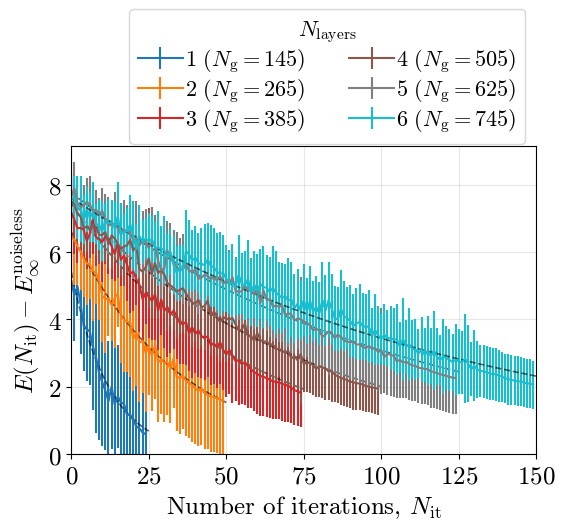

Saved Figs/convergence_noiseless.pdf


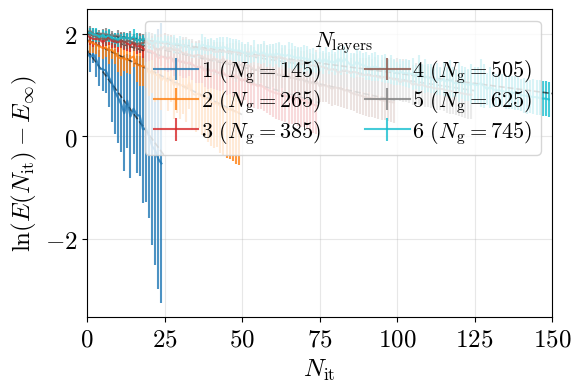

Saved Figs/convergence_noiseless_log.pdf


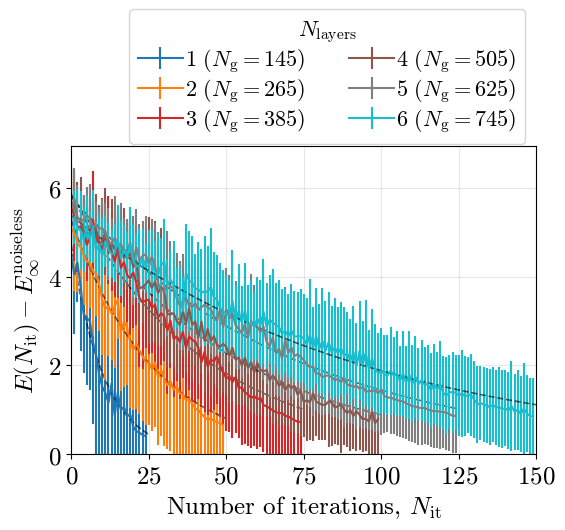

Saved Figs/convergence_mitigated.pdf


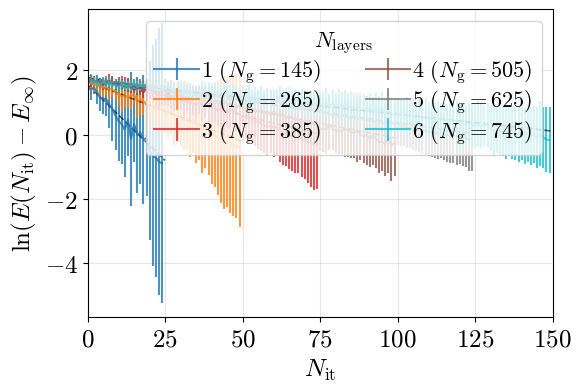

Saved Figs/convergence_mitigated_log.pdf


In [5]:
def plot_convergence(mean_traj, std_traj, val_m, panel, fname_main, fname_log):
    fit_ran  = 25
    xlim_max = fit_ran * n_lay
    xx       = np.arange(0, 2500, 1, dtype=int)

    layer_data = []
    for i, (ld, color) in enumerate(zip(layer_list, colors)):
        fit_range = (i + 1) * fit_ran
        yy = mean_traj[ld] - val_m[i]
        sd = std_traj[ld]
        xp, yp, ep = xx[:fit_range], yy[:fit_range], sd[:fit_range]
        fit_params = None
        valid = yp > 1e-8
        if valid.sum() >= 5:
            try:
                fit_params, _ = curve_fit(
                    exp_model, xp[valid], yp[valid],
                    sigma=ep[valid] + 1e-12, absolute_sigma=True,
                    p0=[max(yp[valid]), 0.05],
                    bounds=([0, 1e-8], [np.inf, 10]), maxfev=10000)
            except RuntimeError:
                pass
        layer_data.append((ld, color, xp, yp, ep, valid, fit_params, gate_ctt[i]))

    # Linear scale
    fig, ax = plt.subplots(figsize=(6, 4))
    for ld, color, xp, yp, ep, valid, fit_params, ng in layer_data:
        ax.errorbar(xp, yp, yerr=ep, fmt="-", color=color,
                    label=r"$%d~(N_\text{g}=%d)$" % (ld, ng))
        if fit_params is not None:
            x_f = np.linspace(0, len(xp), 200)
            ax.plot(x_f, exp_model(x_f, *fit_params), "--k", lw=1.2, alpha=0.6)
    ax.set_xlabel(r"$\text{Number of iterations, }N_\text{it}$", fontsize=18)
    ax.set_ylabel(r"$E(N_\text{it}) - E_{\infty}^{\text{noiseless}}$", fontsize=18)
    ax.set_xlim(0, xlim_max)
    ax.set_ylim(bottom=0)
    ax.xaxis.set_major_formatter(_mfmt)
    ax.yaxis.set_major_formatter(_mfmt)
    ax.legend(ncol=2, loc="upper right", title=r"$N_\text{layers}$", bbox_to_anchor=(1.0, 1.48),
              fontsize=16, title_fontsize=16, labelspacing=0.1, handletextpad=0.1)
    ax.grid(True, alpha=0.3)
    fig.savefig(f"../../figures/{fname_main}", bbox_inches="tight", dpi=300)
    plt.show()
    print(f"Saved ../../figures/{fname_main}")

    # Log-linear
    fig, ax = plt.subplots(figsize=(6, 4))
    for ld, color, xp, yp, ep, valid, fit_params, ng in layer_data:
        log_yp = np.log(yp[valid])
        log_ep = ep[valid] / (yp[valid] + 1e-12)
        ax.errorbar(xp[valid], log_yp, yerr=log_ep, fmt="-", alpha=0.8, color=color,
                    label=r"$%d~(N_\text{g}=%d)$" % (ld, ng))
        if fit_params is not None:
            x_f = np.linspace(0, len(xp), 200)
            ax.plot(x_f, np.log(exp_model(x_f, *fit_params)), "--k", alpha=0.6, lw=1.2)
    ax.set_xlabel(r"$N_\text{it}$", fontsize=18)
    ax.set_ylabel(r"$\ln(E(N_\text{it}) - E_{\infty})$", fontsize=18)
    ax.set_xlim(0, xlim_max)
    ax.xaxis.set_major_formatter(_mfmt)
    ax.yaxis.set_major_formatter(_mfmt)
    ax.legend(ncol=2, loc="upper right", title=r"$N_\text{layers}$",
              fontsize=16, title_fontsize=16, labelspacing=0.1, handletextpad=0.1)
    ax.grid(True, alpha=0.3)
    fig.savefig(f"../../figures/{fname_log}", bbox_inches="tight", dpi=300)
    plt.show()
    print(f"Saved ../../figures/{fname_log}")

plot_convergence(nl_mean_traj, nl_std_traj, val_list_idm,
                 "a", "convergence_noiseless.pdf", "convergence_noiseless_log.pdf")
plot_convergence(mit_mean_traj, mit_std_traj, mit_val_m,
                 "b", "convergence_mitigated.pdf", "convergence_mitigated_log.pdf")

## (c) — E_∞ vs N_g  
Noiseless, noisy (no mitigation), mitigated, E_gs, and depolarising model curve

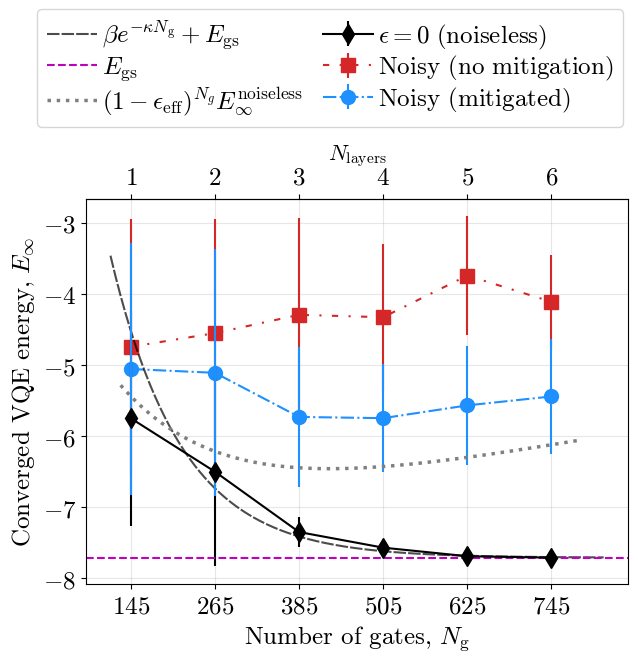

Saved Figs/Einf_vs_Ng.png


In [6]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.errorbar(gate_ctt, val_list_idm, yerr=val_list_ids,
            fmt="d-", markersize=10, color="black",
            label=r"$\epsilon = 0~\text{(noiseless)}$")
ax.plot(x_fit, y_fit + exact_energy, color="black", lw=1.5, alpha=0.7,
        linestyle=(0, (6, 1)),
        label=r"$\beta e^{-\kappa N_\text{g}} + E_\text{gs}$")
ax.errorbar(_bl_Ng, val_ny_m, yerr=val_ny_s,
            fmt="s", markersize=10, color="#D62728", linestyle=(0, (3, 5, 1, 5)),
            barsabove=True, label=r"$\text{Noisy (no mitigation)}$")
ax.errorbar(gate_ctt, mit_val_m, yerr=mit_val_s,
            fmt="o", markersize=10, color="#1E90FF", linestyle="-.",
            barsabove=True, label=r"$\text{Noisy (mitigated)}$")
ax.axhline(exact_energy, color="m", linestyle="--", lw=1.5, label=r"$E_\text{gs}$")

if eps_eff is not None:
    Ng_s      = np.linspace(gate_ctt[0] * 0.9, gate_ctt[-1] * 1.05, 300)
    Einf_nl_s = beta_fit * np.exp(-kappa_fit * Ng_s) + exact_energy
    ax.plot(Ng_s, (1 - eps_eff) ** Ng_s * Einf_nl_s, ":", color="gray", lw=2.5,
            label=r"$(1-\epsilon_{\rm eff})^{N_g} E_\infty^{\rm noiseless}$")

ax.set_xlabel(r"$\text{Number of gates, }N_\text{g}$", fontsize=18)
ax.set_ylabel(r"$\text{Converged VQE energy,}~E_\infty$", fontsize=18)
ax.set_xticks(gate_ctt)
ax.set_xticklabels([f"${v}$" for v in gate_ctt])
ax.yaxis.set_major_formatter(_mfmt)
axx = ax.secondary_xaxis("top")
axx.set_xticks(gate_ctt)
axx.set_xticklabels([f"${v}$" for v in np.arange(1, n_lay + 1, dtype=int)])
axx.set_xlabel(r"$N_\text{layers}$", fontsize=16)
ax.legend(ncol=2, loc="upper center", bbox_to_anchor=(0.45, 1.525),
          labelspacing=0.1, columnspacing=0.8, handletextpad=0.2, fontsize=18)
ax.grid(True, alpha=0.3)
#plt.savefig("../../figures/Einf_vs_Ng.png", bbox_inches="tight", dpi=300)
plt.show()
print("Saved ../../figures/Einf_vs_Ng.png")

## (d) — E_∞ - E_gs vs N_g, linear scale  
Exponential fit `β·exp(-κ·N_g)` to noiseless data

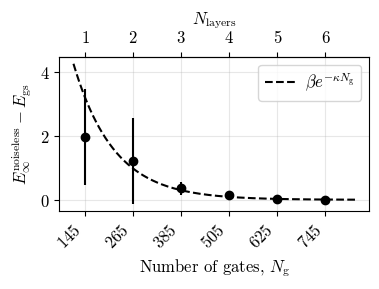

Saved Figs/Einf_fit.pdf


In [7]:
fig, ax = plt.subplots(figsize=(4, 2))
ax.errorbar(gate_ctt, y_data, yerr=y_err, fmt=".", markersize=12, color="black")
ax.plot(x_fit, y_fit, "--k", lw=1.5,
        label=rf"$\beta e^{{-\kappa N_\text{{g}}}}$")
ax.set_xlabel(r"$\text{Number of gates, }N_\text{g}$", fontsize=12)
ax.set_ylabel(r"$E_\infty^\text{noiseless} - E_\text{gs}$", fontsize=12)
ax.set_xticks(gate_ctt)
ax.set_xticklabels([f"${v}$" for v in gate_ctt], rotation=45, ha="right", fontsize=12)
ax.yaxis.set_major_formatter(_mfmt)
ax.tick_params(axis="y", labelsize=12)
axx = ax.secondary_xaxis("top")
axx.set_xticks(gate_ctt)
axx.set_xticklabels([f"${v}$" for v in np.arange(1, n_lay + 1, dtype=int)], fontsize=12)
axx.set_xlabel(r"$N_\text{layers}$", fontsize=12)
ax.legend(fontsize=12, loc="upper right", handletextpad=0.4)
ax.grid(True, alpha=0.3)
plt.savefig("../../figures/Einf_fit.pdf", bbox_inches="tight", dpi=300)
plt.show()
print("Saved ../../figures/Einf_fit.pdf")

## (d') — E_∞ - E_gs vs N_g, log-linear scale

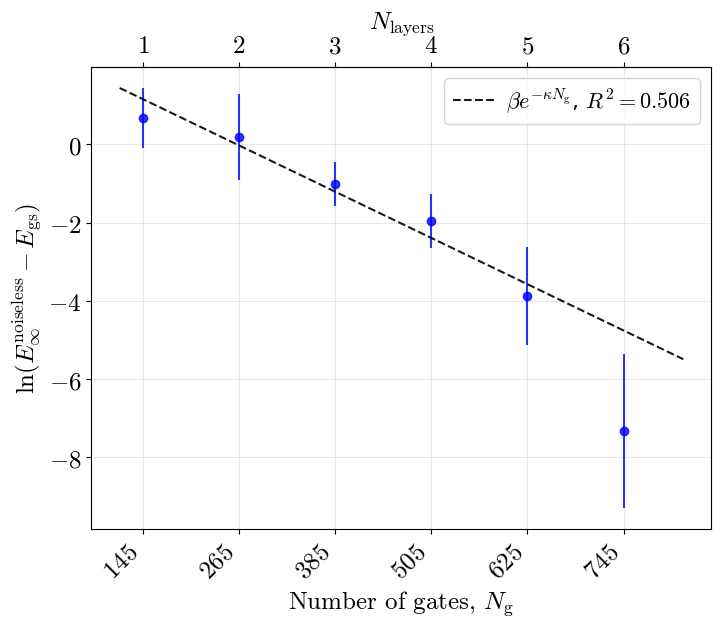

Saved Figs/Einf_fit_loglin.pdf


In [8]:
log_y = np.log(np.where(y_data > 0, y_data, np.nan))
log_e = np.where(y_data > 0, y_err / y_data, np.nan)

fig, ax = plt.subplots(figsize=(8, 6))
ax.errorbar(gate_ctt, log_y, yerr=log_e, fmt=".", markersize=12, color="blue", alpha=0.8)
ax.plot(x_fit, np.log(y_fit), "--k", lw=1.5, alpha=0.9,
        label=rf"$\beta e^{{-\kappa N_\text{{g}}}}$, $R^2={r_sq:.3f}$")
ax.set_xlabel(r"$\text{Number of gates, }N_\text{g}$", fontsize=18)
ax.set_ylabel(r"$\ln(E_\infty^\text{noiseless} - E_\text{gs})$", fontsize=18)
ax.set_xticks(gate_ctt)
ax.set_xticklabels([f"${v}$" for v in gate_ctt], rotation=45, ha="right")
ax.yaxis.set_major_formatter(_mfmt)
axx = ax.secondary_xaxis("top")
axx.set_xticks(gate_ctt)
axx.set_xticklabels([f"${v}$" for v in np.arange(1, n_lay + 1, dtype=int)])
axx.set_xlabel(r"$N_\text{layers}$", fontsize=18)
ax.legend(fontsize=16, loc="upper right", handletextpad=0.4)
ax.grid(True, alpha=0.3)
plt.savefig("../../figures/Einf_fit_loglin.pdf", bbox_inches="tight", dpi=300)
plt.show()
print("Saved ../../figures/Einf_fit_loglin.pdf")

## (e) — μ vs N_g, log-log  
Power-law fit `μ₀·N_g^{-λ}` to noiseless μ values; mitigated μ overlaid

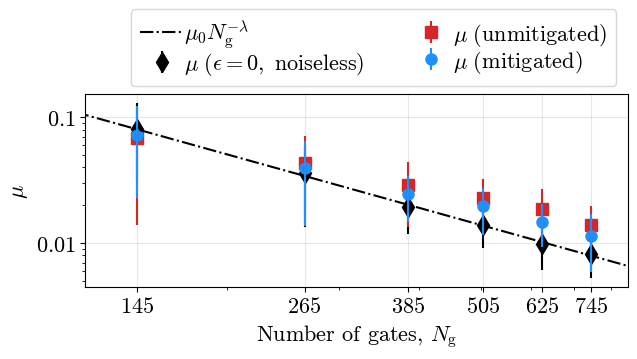

In [10]:
x_fit_mu = np.linspace(gate_ctt[0] * 0.8, gate_ctt[-1] * 1.2, 1000)
y_fit_mu = noiseless_power_model(x_fit_mu, mu_a, mu_b)

fig, ax = plt.subplots(figsize=(7, 2.5))
ax.errorbar(gate_ctt[valid_nl], mu_nl_mean[valid_nl], yerr=mu_nl_err[valid_nl],
            fmt="d", color="black", markersize=10, barsabove=True,
            label=r"$\mu~(\epsilon = 0,~\text{noiseless})$")
ax.plot(x_fit_mu, y_fit_mu, "-.k", lw=1.5,
        label=rf"$\mu_0 N_\text{{g}}^{{-\lambda}}$")
if valid_ny.sum() >= 2:
    ax.errorbar(_bl_Ng[valid_ny], mu_ny_mean[valid_ny], yerr=mu_ny_err[valid_ny],
                fmt="s", color="#D62728", markersize=8, barsabove=True,
                label=r"$\mu~\text{(unmitigated)}$")
if valid_mit.sum() >= 2:
    ax.errorbar(gate_ctt[valid_mit], mu_mit_mean[valid_mit], yerr=mu_mit_err[valid_mit],
                fmt="o", color="#1E90FF", markersize=8, barsabove=True,
                label=r"$\mu~\text{(mitigated)}$")
ax.set_xlabel(r"$\text{Number of gates, }N_\text{g}$", fontsize=16)
ax.set_ylabel(r"$\mu$", fontsize=16)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xticks(gate_ctt)
ax.set_xlim([120, 850])
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.xaxis.set_minor_formatter(mticker.NullFormatter())
ax.set_xticklabels([f"${v}$" for v in gate_ctt], rotation=0, fontsize=16)
ax.yaxis.set_major_formatter(_mfmt)
ax.tick_params(axis="y", labelsize=16)
ax.legend(ncol=2, loc="upper right", bbox_to_anchor=(1, 1.5),
          labelspacing=0, handletextpad=0, fontsize=16)
ax.grid(True, alpha=0.3)
#plt.savefig("../../figures/mu_vs_Ng.png", bbox_inches="tight", dpi=300)
plt.show()
#print("Saved ../../figures/mu_vs_Ng.png")

## (f) — Depolarising residual (signed)  
`E_∞^mit - (1-ε_eff)^{N_g} · E_∞^nl`

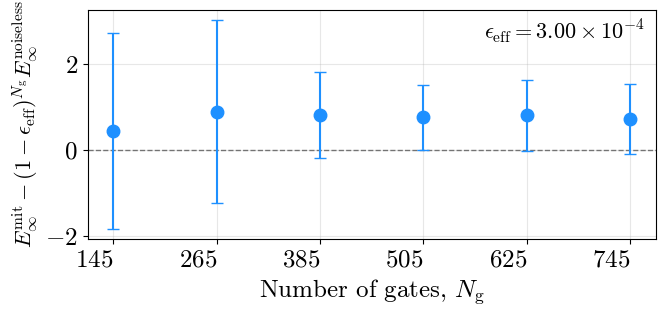

Saved Figs/depol_residual_signed.png


In [84]:
if eps_eff is None:
    print("[SKIP] eps_eff not available in saved data.")
else:
    scale        = (1.0 - eps_eff) ** gate_ctt
    residual     = mit_val_m - scale * val_list_idm
    residual_err = np.sqrt(mit_val_s**2 + (scale * val_list_ids)**2)

    _e = int(np.floor(np.log10(abs(eps_eff))))
    _m = eps_eff / 10**_e
    _eps_tex = rf"$\epsilon_{{\rm eff}} = {_m:.2f} \times 10^{{{_e}}}$"

    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.axhline(0, color="k", lw=1, linestyle="--", alpha=0.5)
    ax.errorbar(gate_ctt, residual, yerr=residual_err,
                fmt="o", color="#1E90FF", markersize=9, barsabove=True, capsize=4)
    ax.set_xlabel(r"$\text{Number of gates, }N_\text{g}$", fontsize=18)
    ax.set_ylabel(
        r"$E_\infty^\text{mit} - (1-\epsilon_\text{eff})^{N_\text{g}} E_\infty^\text{noiseless}$",
        fontsize=16)
    ax.set_xticks(gate_ctt)
    ax.set_xticklabels([f"${v}$" for v in gate_ctt], rotation=0, ha="right")
    ax.yaxis.set_major_formatter(_mfmt)
    ax.text(0.98, 0.97, _eps_tex,
            transform=ax.transAxes, fontsize=16,
            va="top", ha="right")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("../../figures/depol_residual_signed.png", bbox_inches="tight", dpi=300)
    plt.show()
    print("Saved ../../figures/depol_residual_signed.png")

## (f') — Depolarising residual (|residual|, log scale)  
Model residual vs uncorrected bias

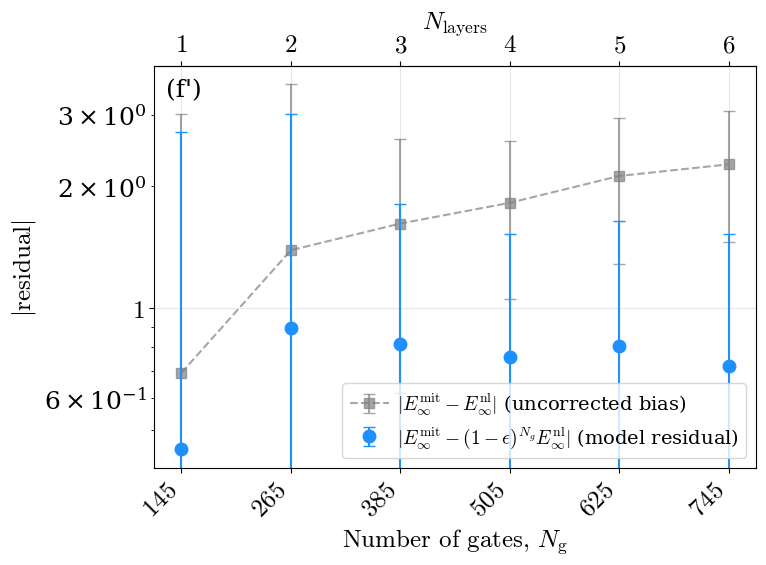

Saved Figs/depol_residual_abs.pdf


In [78]:
if eps_eff is None:
    print("[SKIP] eps_eff not available in saved data.")
else:
    abs_res      = np.abs(residual)
    raw_bias     = np.abs(mit_val_m - val_list_idm)
    raw_bias_err = np.sqrt(val_list_ids**2 + mit_val_s**2)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.errorbar(gate_ctt, raw_bias, yerr=raw_bias_err,
                fmt="s", color="gray", markersize=7, barsabove=True, capsize=4,
                alpha=0.7, linestyle="--",
                label=r"$|E_\infty^\text{mit} - E_\infty^\text{nl}|$ (uncorrected bias)")
    ax.errorbar(gate_ctt, abs_res, yerr=residual_err,
                fmt="o", color="#1E90FF", markersize=9, barsabove=True, capsize=4,
                label=r"$|E_\infty^\text{mit} - (1-\epsilon)^{N_g} E_\infty^\text{nl}|$ (model residual)")
    ax.set_xlabel(r"$\text{Number of gates, }N_\text{g}$", fontsize=18)
    ax.set_ylabel(r"$|\text{residual}|$", fontsize=18)
    ax.set_yscale("log")
    ax.set_xticks(gate_ctt)
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())
    ax.set_xticklabels([f"${v}$" for v in gate_ctt], rotation=45, ha="right")
    ax.yaxis.set_major_formatter(_mfmt)
    axx = ax.secondary_xaxis("top")
    axx.set_xticks(gate_ctt)
    axx.set_xticklabels([f"${v}$" for v in np.arange(1, n_lay + 1, dtype=int)])
    axx.set_xlabel(r"$N_\text{layers}$", fontsize=18)
    ax.legend(fontsize=14, loc="lower right", labelspacing=0.4, handletextpad=0.4)
    ax.text(0.02, 0.97, "(f')", transform=ax.transAxes, fontsize=18, va="top")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("../../figures/depol_residual_abs.pdf", bbox_inches="tight", dpi=300)
    plt.show()
    print("Saved ../../figures/depol_residual_abs.pdf")

## Fit parameter tables  
LaTeX output (copy-paste ready) + matplotlib rendering

Table 1 — Model fit parameters
\begingroup
\setlength{\tabcolsep}{6pt}
\renewcommand{\arraystretch}{1.5}
\begin{table}[h]
\begin{center}
\begin{tabular}{c | c | c}
\hline
Parameter & Noiseless ($\epsilon = 0$) & Mitigated (ZNE/linear/gate-fold) \\ [0.5ex]
\hline
$\beta$ & $13.350$ & $421.629$ \\
\hline
$\kappa$ & $0.010$ & $0.010$ (fixed) \\
\hline
$R^2$ (linear) & $0.5062$ & $-2.321 \times 10^{4}$ \\
\hline
$R^2$ (log) & $0.8382$ & $-316.8609$ \\
\hline
$\mu_0$ & $89.350 \pm 210.682$ & $18.596 \pm 47.864$ \\
\hline
$\lambda$ & $1.410 \pm 0.382$ & $1.109 \pm 0.419$ \\
\hline
$\epsilon_{\rm eff}$ & --- & $3.00 \times 10^{-4}$ \\
\hline
\end{tabular}
\end{center}
\caption{Model fit parameters.}
\label{table:fit_params}
\end{table}
\endgroup

Table 2 — Per-layer converged energies
\begingroup
\setlength{\tabcolsep}{6pt}
\renewcommand{\arraystretch}{1.5}
\begin{table}[h]
\begin{center}
\begin{tabular}{c | c | c | c}
\hline
$N_{\rm layers}$ & $N_{\rm g}$ & $E_\infty^{\rm nl}$ & $E_\infty^{\

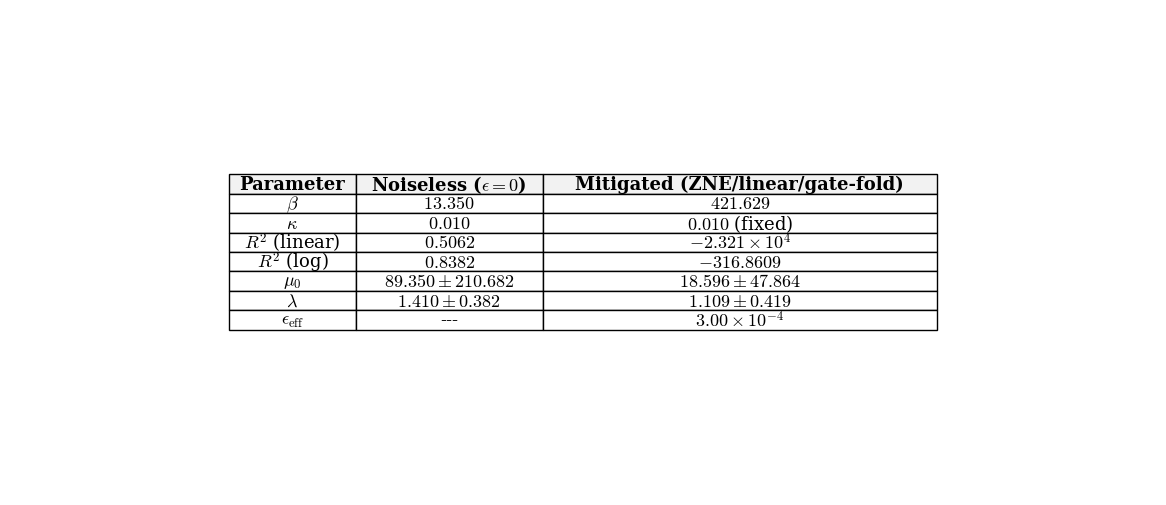

Saved Figs/fit_params_table.pdf


In [79]:
def _fmt(x, dec=3):
    if not np.isfinite(x): return r"---"
    if x == 0.0: return "0"
    if 0.001 <= abs(x) < 1000: return f"{x:.{dec}f}"
    exp  = int(np.floor(np.log10(abs(x))))
    return rf"{x / 10**exp:.{dec-1}f} \times 10^{{{exp}}}"

def _fmt_pm(val, err, dec=3):
    if not np.isfinite(val): return r"---"
    if val == 0.0: return "0"
    if 0.001 <= abs(val) < 1000: return rf"{val:.{dec}f} \pm {err:.{dec}f}"
    exp = int(np.floor(np.log10(abs(val))))
    return rf"({val/10**exp:.{dec-1}f} \pm {err/10**exp:.{dec-1}f}) \times 10^{{{exp}}}"

# β_mit: single-parameter fit with κ fixed to noiseless value
y_mit     = mit_val_m - exact_energy
pos       = y_mit > 0
kappa_mit = kappa_plot
beta_mit  = r_sq_mit_lin = r_sq_mit_log = np.nan
if pos.sum() >= 1:
    try:
        def _intercept_model(Ng, log_beta): return log_beta - kappa_mit * Ng
        sig_log_mit = np.divide(mit_val_s[pos], y_mit[pos])
        pm_mit, _   = curve_fit(_intercept_model, gate_ctt[pos], np.log(y_mit[pos]),
                                sigma=sig_log_mit, absolute_sigma=True)
        beta_mit    = np.exp(pm_mit[0])
        y_pred_lin  = exp_model(gate_ctt[pos], beta_mit, kappa_mit)
        ss_r = np.sum((y_mit[pos] - y_pred_lin)**2)
        ss_t = np.sum((y_mit[pos] - np.mean(y_mit[pos]))**2)
        r_sq_mit_lin = 1 - ss_r/ss_t if ss_t > 1e-12 else 0.0
        log_yd = np.log(y_mit[pos])
        log_yp = pm_mit[0] - kappa_mit * gate_ctt[pos]
        ss_r = np.sum((log_yd - log_yp)**2)
        ss_t = np.sum((log_yd - np.mean(log_yd))**2)
        r_sq_mit_log = 1 - ss_r/ss_t if ss_t > 1e-12 else 0.0
    except RuntimeError: pass

# μ₀_mit, λ_mit
mu0_mit = lam_mit = mu0_mit_err = lam_mit_err = np.nan
if valid_mit.sum() >= 2:
    try:
        pm_mu_mit, cv_mu_mit = curve_fit(
            noiseless_power_model, gate_ctt[valid_mit], mu_mit_mean[valid_mit],
            sigma=mu_mit_err[valid_mit], absolute_sigma=True,
            p0=[1.0, 0.5], bounds=([0, 0], [np.inf, 5]))
        mu0_mit, lam_mit         = pm_mu_mit
        mu0_mit_err, lam_mit_err = np.sqrt(np.diag(cv_mu_mit))
    except RuntimeError: pass

_eps_str = _fmt(eps_eff) if eps_eff is not None else r"---"
_col_nl  = r"Noiseless ($\epsilon = 0$)"
_col_mit = f"Mitigated ({MITIGATION_LABEL})"

_rows = [
    (r"$\beta$",                  f"${_fmt(beta_plot)}$",           f"${_fmt(beta_mit)}$"),
    (r"$\kappa$",                 f"${_fmt(kappa_plot)}$",          f"${_fmt(kappa_mit)}$ (fixed)"),
    (r"$R^2$ (linear)",          f"${_fmt(r_sq, dec=4)}$",         f"${_fmt(r_sq_mit_lin, dec=4)}$"),
    (r"$R^2$ (log)",             f"${_fmt(r_sq_log, dec=4)}$",     f"${_fmt(r_sq_mit_log, dec=4)}$"),
    (r"$\mu_0$",                  f"${_fmt_pm(mu_a, mu_a_err)}$",  f"${_fmt_pm(mu0_mit, mu0_mit_err)}$"),
    (r"$\lambda$",                f"${_fmt_pm(mu_b, mu_b_err)}$",  f"${_fmt_pm(lam_mit, lam_mit_err)}$"),
    (r"$\epsilon_{\rm eff}$",    "---",                              f"${_eps_str}$"),
]

# ── LaTeX Table 1 ─────────────────────────────────────────────────────────────
print("=" * 72)
print("Table 1 — Model fit parameters")
print("=" * 72)
lines = [
    r"\begingroup", r"\setlength{\tabcolsep}{6pt}",
    r"\renewcommand{\arraystretch}{1.5}",
    r"\begin{table}[h]", r"\begin{center}",
    r"\begin{tabular}{c | c | c}", r"\hline",
    rf"Parameter & {_col_nl} & {_col_mit} \\ [0.5ex]", r"\hline",
]
for param, nl_v, mit_v in _rows:
    lines += [rf"{param} & {nl_v} & {mit_v} \\", r"\hline"]
lines += [r"\end{tabular}", r"\end{center}",
          r"\caption{Model fit parameters.}", r"\label{table:fit_params}",
          r"\end{table}", r"\endgroup"]
print("\n".join(lines))

# ── LaTeX Table 2 ─────────────────────────────────────────────────────────────
print("\n" + "=" * 72)
print("Table 2 — Per-layer converged energies")
print("=" * 72)
lines2 = [
    r"\begingroup", r"\setlength{\tabcolsep}{6pt}",
    r"\renewcommand{\arraystretch}{1.5}",
    r"\begin{table}[h]", r"\begin{center}",
    r"\begin{tabular}{c | c | c | c}", r"\hline",
    rf"$N_{{\rm layers}}$ & $N_{{\rm g}}$ & $E_\infty^{{\rm nl}}$ & $E_\infty^{{\rm mit}}$ \\ [0.5ex]",
    r"\hline",
]
for i, ld in enumerate(layer_list):
    lines2 += [
        rf"{ld} & {gate_ctt[i]} & ${val_list_idm[i]:.4f} \pm {val_list_ids[i]:.4f}$ & ${mit_val_m[i]:.4f} \pm {mit_val_s[i]:.4f}$ \\",
        r"\hline",
    ]
lines2 += [r"\end{tabular}", r"\end{center}",
           rf"\caption{{Per-layer converged energies. $E_{{\rm gs}}={exact_energy:.4f}$.}}",
           r"\label{table:Einf_layers}", r"\end{table}", r"\endgroup"]
print("\n".join(lines2))

# ── matplotlib table ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 0.6 * len(_rows) + 1.2))
ax.axis("off")
tbl = ax.table(cellText=[[p, nl, m] for p, nl, m in _rows],
               colLabels=["Parameter", _col_nl, _col_mit],
               cellLoc="center", loc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(13)
tbl.auto_set_column_width([0, 1, 2])
for col in range(3):
    tbl[0, col].set_facecolor("#f2f2f2")
    tbl[0, col].set_text_props(fontweight="bold")
plt.tight_layout()
plt.savefig("../../figures/fit_params_table.pdf", bbox_inches="tight", dpi=300)
plt.show()
print("Saved ../../figures/fit_params_table.pdf")